## Przygotowanie

Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko.
{nr_albumu}\_{imię}\_{nazwisko}\_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez TEAMS w wiadomości prywatnej.

## Regresja liniowa wieloraka

Rzadko kiedy zdarza się taka sytuacja, że zależność opisuje się na podstawie tylko jednej zmiennej. Z reguły na wynik zmiennej objaśnianej ($y$) ma wpły więcej różnych cech. Przykładowo, na cenę samochodu ma wpływ rok produkcji, przebieg, ilość koni mechanicznych itp. Dlatego właśnie jest naturalna potrzeba rozwinięcia algorytmu regresji liniowej z jedną cechą na większą ilość cech.

Algorytm, który implementowaliśmy w poprzednim zadaniu jest szczególnym przypadkiem regresji liniowej, ale może zostać on w łatwy sposób uogólniony. Mechanizmy, które poznaliśmy wcześniej takie jak obliczanie funkcji błędu, pochodnych cząstkowych, w dalszym ciągu są aktualne. Trzeba jedynie uwzględnić dodatkowe cechy.

### Zadanie 1

W zbiorze danych z zarobkami, który wykorzystywany był w poprzednim zadaniu, znajduje się pominięta wcześniej cecha. Wczytaj dane z pliku Salary.csv, tym razem z dwiema zmiennymi objaśniającymi: YearsExperience i Age oraz zmienną objaśnianą Salary. Stwórz wykres 3D przedstawiający dane.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np

df = pd.read_csv('../P1 - regresja liniowa prosta/Salary.csv', sep=',')

In [2]:
df.head()

,YearsExperience,Age,Salary
0,1.1,20,39343
1,1.3,21,46205
2,1.5,21,37731
3,2.0,22,43525
4,2.2,22,39891


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  35 non-null     float64
 1   Age              35 non-null     int64  
 2   Salary           35 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 972.0 bytes


In [4]:
df.describe()

,YearsExperience,Age,Salary
count,35.000000,35.000000,35.000000
mean,6.308571,28.371429,83888.428571
std,3.618610,5.568217,32200.112889
min,1.100000,20.000000,37731.000000
25%,3.450000,24.000000,57019.000000
50%,5.300000,27.000000,81363.000000
75%,9.250000,32.500000,113223.500000
max,13.500000,40.000000,139465.000000


In [5]:
#%matplotlib notebook

Text(0.5, 0.92, 'Zarobki w zależności od doświadczenia i wieku')

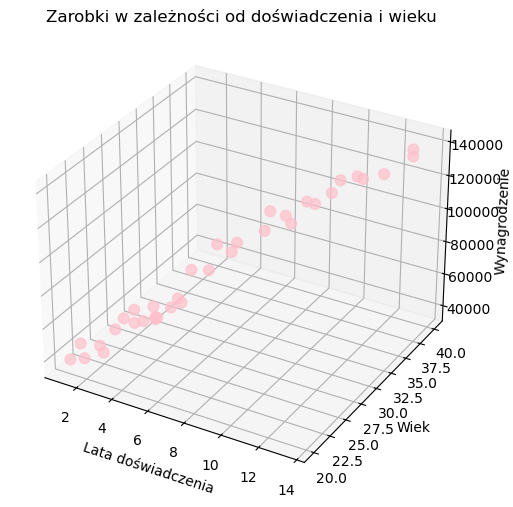

In [6]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

x = df['YearsExperience']
y = df['Age']
z = df['Salary']

ax.scatter(x, y, z, c='pink', s=60, alpha=0.7)

ax.set_xlabel('Lata doświadczenia')
ax.set_ylabel('Wiek')
ax.set_zlabel('Wynagrodzenie')

ax.set_title('Zarobki w zależności od doświadczenia i wieku')


## Zadanie 2

Przerób algorytm znajdujący się w funkcji _learn_and_fit(x,y)_ w taki sposób, aby uwzględniał dodatkową cechę.
Funkcja regresji liniowej przybierze w tym momencie postać:

\begin{equation}
f(x^{(i)}) = \beta_{0} + \beta_{1}x_1 + \beta_{2}x_2 = \beta_{0} + \beta_{1} YearsExperience + \beta_{2} Age
\end{equation}

Pojawienie się kolejnej cechy wymaga akutalizacji obliczania gradientu. Należy dodatkowo obliczyć pochodną cząstkową względem parametru $\beta_{2}$, a następnie zaktualizować wartość tego parametru. 

Obliczenie pochodnej cząstkowej wygląda analogicznie jak w przypadku parametru $\beta_{1}$.

\begin{equation}
    \frac{\partial SSR}{\partial \beta_{2}} = \frac{1}{n} \sum^{n}_{i=1} (f(x^{(i)}) - y^{(i)})x_{1}^{(i)}
\end{equation}

Aktualizacja wartości współczynnika również jest analogiczna.

\begin{equation}
    \beta_{2} = \beta_{2} - \alpha \frac{\partial SSR}{\partial \beta_{2}} 
\end{equation}

_Uwaga: Zastanów się, w jaki sposób zaimplementować obługę kolejnych cech, tak aby po pojawieniu się 3 cechy nie trzeba było modyfikować algorytmu._

In [7]:
import random
from typing import Tuple, List


def initialize_coefficients(n: int = 2, alpha: float = 0.01) -> Tuple[float, np.ndarray]:
    eps = np.finfo(float).eps
    betas = np.random.uniform(eps, 1 - eps, size=n)
    return alpha, betas


def calculate_regression_function(X: np.ndarray, betas: np.ndarray) -> np.ndarray:
    return betas[0] + X.dot(betas[1:])


def calculate_error(predictions: np.ndarray, y: np.ndarray) -> float:
    m = len(predictions)
    return (1.0 / (2 * m)) * np.sum((predictions - y) ** 2)


def calculate_gradient(X: np.ndarray, predictions: np.ndarray, y: np.ndarray) -> np.ndarray:
    m = len(predictions)
    error = predictions - y

    grad_0 = np.sum(error) / m
    grad_rest = (X.T.dot(error)) / m
    return np.hstack([grad_0, grad_rest])


def update_regression_coefficients(X: np.ndarray, predictions: np.ndarray, y: np.ndarray, betas: np.ndarray,
                                   alpha: float) -> np.ndarray:
    d_betas = calculate_gradient(X, predictions, y)
    betas_new = betas - alpha * d_betas
    return betas_new




In [8]:
'''
input:
X - wartości zmiennych objaśniających YearsExperience oraz Age dla wszystkich obserwacji
y - wartości zmiennej objaśnianej Salary dla wszystkich obserwacji

output:
b0: [] - lista z współczynnikami beta_0 w każdej z epok
betas: [] - lista z współczynnikami beta_1, beta_2 w każdej z epok
error: [] - lista z błędem w każdej epoce
'''


def learn_and_fit(X: np.ndarray, y: np.ndarray, alpha: float = 0.01) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    epoch = 100
    b0_list = []
    print(len(X))
    betas_list = []
    errors_list = []
    alpha, betas = initialize_coefficients(3, alpha)
    for ep in range(epoch):
        y_pred = calculate_regression_function(X, betas)

        err = calculate_error(y_pred, y)
        betas = update_regression_coefficients(X, y_pred, y, betas, alpha)
        b0_list.append(betas[0])
        betas_list.append(betas[1:])
        errors_list.append(err)

    return np.array(b0_list), np.array(betas_list), np.array(errors_list)




In [9]:
X = df[['YearsExperience', 'Age']].values
y = df['Salary'].values

In [10]:
b0, betas, err = learn_and_fit(X, y, 0.002)

35


Text(0.5, 1.0, 'Zmiana błedu regresji względem epoki')

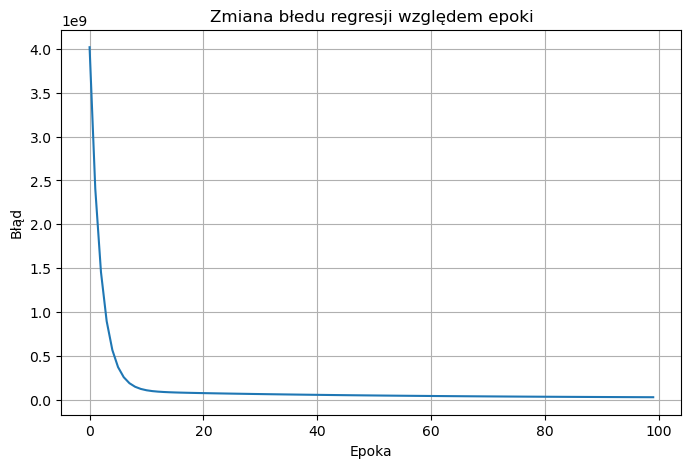

In [11]:
# YOUR CODE HERE
%matplotlib inline

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(range(len(err)), err)
ax.set_xlabel('Epoka')
ax.set_ylabel('Błąd')
ax.grid(True)
ax.set_title('Zmiana błedu regresji względem epoki')



### Zadanie 3

Do stworzonego z zadaniu 1 wykresu dodaj płaszczyznę regresji. Stwórz 3 wykresy przedstawiające jak zmieniała się funkcja regresji na przestrzeni epok (pierwsza, środkowa, ostatnia epoka).

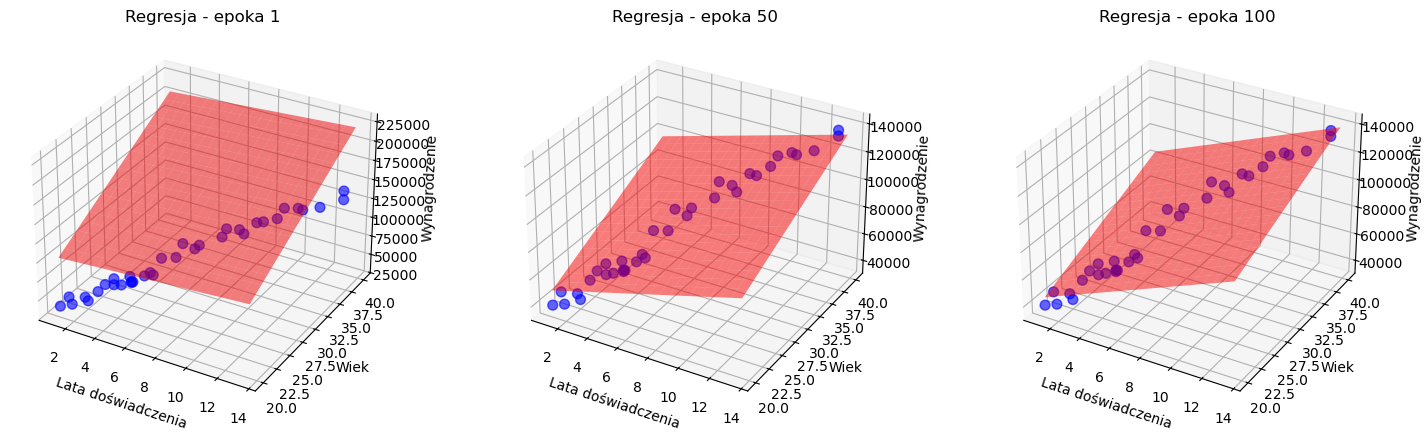

In [12]:
epochs = len(err)
middle_idx = (0 + (epochs - 1)) // 2
epoch_indices = [0, middle_idx, epochs - 1]
x = df['YearsExperience']
y = df['Age']
z = df['Salary']
fig = plt.figure(figsize=(18, 5))

for i, idx in enumerate(epoch_indices):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')

    beta0 = b0[idx]
    beta1 = betas[idx, 0]
    beta2 = betas[idx, 1]

    ax.scatter(x, y, z, c='blue', s=50, alpha=0.6, label='Dane')

    x_surf, y_surf = np.meshgrid(np.linspace(x.min(), x.max(), 20),
                                 np.linspace(y.min(), y.max(), 20))
    z_surf = beta0 + beta1 * x_surf + beta2 * y_surf

    ax.plot_surface(x_surf, y_surf, z_surf, color='red', alpha=0.5)

    ax.set_xlabel('Lata doświadczenia')
    ax.set_ylabel('Wiek')
    ax.set_zlabel('Wynagrodzenie')
    ax.set_title(f'Regresja - epoka {idx + 1}')




### Zadanie 4

W sytuacji, w której zbiór danych zawiera więcej zmiennych objaśniających niż 2, niemożliwym staje się wizualizacja prostej regresji i ocena w taki sposób stworzonego modelu. Bardzo przydatnym rozwiązaniem jest wtedy stworzenie wykresu błędów regresji. Jeśli wartości błędu spadają wraz z kolejnymi epokami, oznacza to, że jesteśmy na dobrej drodze, a nasz algorytm działa poprawnie. Celem tego zadania będzie stworzenie finalnego modelu regresji liniowej, który będzie przyjmował dowolną liczbę zmiennych objaśniających.

Na podstawie wcześniejszych implementacji, stwórz implementację funkcji *learn_and_fit_multi(X, y)*, która będzie przyjmować zbiór wejściowy z dowolną ilością kolum (cech). Dla takiego zbioru zbioru danych ma zostać stworzony model regresji. Funkcja podobnie jak wcześniej, ma zwracać współczynniki oraz wartość błędu w każdej epoce. 

W notebooku z opisem regresji liniowej przedstawione zostały wzory na ogólą postać regresji. Przeanalizuj je jeszcze raz i postaraj się je zaimplementować.

Wczytaj zestaw danych *multi_variable_regression.csv* z katalogu datasets. Dane wygenerowane zostały w taki sposób, że są wysoce liniowo zależne. Wartość błędu dla nauczonego modelu powinna być w takim przypadku niewielka. Przetestuj na wczytanym zbiorze swój algorytm.

In [13]:
def learn_and_fit_multi(X: np.ndarray, y: np.ndarray, alpha: float = 0.01, stop: float = 0.00001) -> Tuple[
    np.ndarray, np.ndarray, np.ndarray]:
    epoch = 100
    b0_list = []
    betas_list = []
    errors_list = []
    alpha, betas = initialize_coefficients(X.shape[1] + 1, alpha)
    for ep in range(epoch):
        y_pred = calculate_regression_function(X, betas)
        err = calculate_error(y_pred, y)
        betas = update_regression_coefficients(X, y_pred, y, betas, alpha)
        b0_list.append(betas[0])
        betas_list.append(betas[1:])
        errors_list.append(err)
        if err < stop:
            print(round(err, 2), stop)
            print(f'Błąd został osiągnięty przy epoce {ep}')
            break

    return np.array(b0_list), np.array(betas_list), np.array(errors_list)


In [14]:
df2 = pd.read_csv('multi_variable_regression.csv')

In [15]:
df2.head()

,x1,x2,x3,x4,x5,x6,y
0,-0.586479,0.457946,0.611877,1.234197,0.345695,0.574824,177.111999
1,-0.101979,-0.330872,0.391967,-0.238672,0.736806,-0.934582,-134.845687
2,-0.704671,-1.156918,0.510129,0.468877,0.402749,0.438787,-29.719439
3,-1.318963,1.030290,0.099815,0.395081,0.315859,-0.621132,-11.984118
4,-1.162739,-0.684766,-0.202388,0.726013,-0.093449,0.944595,47.913451


In [16]:
X2 = df2.drop('y', axis=1)
y2 = df2['y']

In [17]:
b02, betas2, err2 = learn_and_fit_multi(X2, y2, alpha=0.3, stop=0.0000000001)

0.0 1e-10
Błąd został osiągnięty przy epoce 63


In [18]:
print(err2[24], err2[1])

0.012377052194640177 5875.699379221945


### Zadanie 5

Stwórz wykres przedstawiający zmianę błędu regresji w kolejnych epokach. Napisz co można na jego podstawie wywnioskować.

Text(0.5, 1.0, 'Zmiana błedu regresji względem epoki')

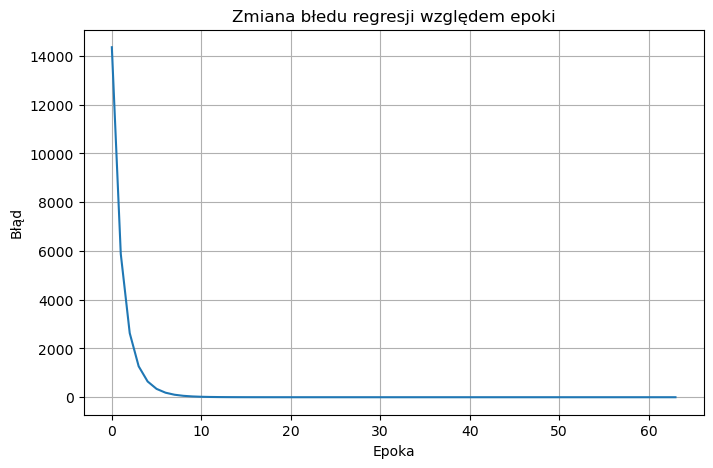

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(range(len(err2)), err2)
ax.set_xlabel('Epoka')
ax.set_ylabel('Błąd')
ax.grid(True)
ax.set_title('Zmiana błedu regresji względem epoki')


Z wykresu można zauważyć, że przez pierwsze ~5 epok następuje gwałtowny spadek błędu. Po tym momencie wartość błędu zaczyna się stabilizować co sugeruje, że kolejne epoki nie są już takie kluczowe - do tego momentu najważniejsze wzorce zostały uchwycone. Punk ten może sugerować, że dalsze trenowanie może zwiększać prawdopodobieństwo overfittingu. Dołożenie do tego wykresu wartości błędu na zbiorze testowym mogłoby to potwierdzić i wskazać, w którym momencie dalsze trenowanie wpływa negatywnie na generalizację problemu.

### Zadanie 6

W jaki sposób współczynnik alpha wpływa na działania algorytmu? Przeprowadź eksperyment dla minimum trzech różnych wartości tego parametru. Sformułuj wnioski. Jak zmiana parametru wpłynęła na ilość epok w algorytmie? Jak zmieniła się funkcja regresji?

In [20]:
alpha_list = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 2]

for alpha in alpha_list:
    print(f'Dla alpha = {alpha}')
    b03, betas3, err3 = learn_and_fit_multi(X2, y2, alpha, 0.0000001)

    b0_final = b03[-1]
    coefs = betas3[-1]
    terms = [f"{coefs[j]:.5f}*x{j+1}" for j in range(len(coefs))]
    formula = " + ".join(terms)
    print(f"Dla alpha = {alpha:.4f} wzór funkcji regresji to: {b0_final:.4f} + {formula}")
    print(f'Wartość błędu wynosi: {err3[-1]}\n\n')

Dla alpha = 0.001
Dla alpha = 0.0010 wzór funkcji regresji to: 3.0359 + 6.87953*x1 + 10.27617*x2 + -1.98887*x3 + 9.17847*x4 + 0.77101*x5 + 9.65754*x6
Wartość błędu wynosi: 11319.561965936764


Dla alpha = 0.01
Dla alpha = 0.0100 wzór funkcji regresji to: 6.8763 + 38.00796*x1 + 54.43160*x2 + -8.83882*x3 + 58.76132*x4 + 2.79237*x5 + 60.61886*x6
Wartość błędu wynosi: 1532.1927250324716


Dla alpha = 0.05
Dla alpha = 0.0500 wzór funkcji regresji to: 0.1103 + 49.42770*x1 + 73.70321*x2 + 3.17571*x3 + 88.40525*x4 + 8.48791*x5 + 97.57303*x6
Wartość błędu wynosi: 1.4022212112686543


Dla alpha = 0.1
Dla alpha = 0.1000 wzór funkcji regresji to: -0.0069 + 49.48676*x1 + 74.04146*x2 + 4.28179*x3 + 88.89732*x4 + 8.90063*x5 + 98.77776*x6
Wartość błędu wynosi: 0.0005431109813899266


Dla alpha = 0.2
0.0 1e-07
Błąd został osiągnięty przy epoce 76
Dla alpha = 0.2000 wzór funkcji regresji to: -0.0002 + 49.48900*x1 + 74.04700*x2 + 4.30827*x3 + 88.89906*x4 + 8.90984*x5 + 98.79768*x6
Wartość błędu wynosi: 8

Współczynnik alpha wpływa na to jak szybko model się uczy. Im wartość jest wyższa tym szybsza jest zbieżność algorytmu i osiągany wskazany błąd. Dla zbyt niskich wartości alpha wskazany błąd nie został osiągnięty, natomiast dla za wysokiej minimum zostało przeskoczone i wskazany błąd również nie zostaje osiągnięty. Dla współczynników 0.2, 0.3, 0.5 zostaje znalezione rozwiązanie dla 0.2 najpóźniej dla 0.5 najszybciej. Widać również, że dla tych alpha finalny wzór funkcji regresji jest bardzo podobny.

### Zadanie 7

Porównaj czas działania algorytmu we własnej implementacji oraz implementacji z biblioteki Sklearn.

In [21]:
# YOUR CODE HERE
from sklearn.linear_model import LinearRegression

In [22]:
model = LinearRegression()
model.fit(X2, y2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
predicted_sklearn = model.predict(X2)

In [27]:
for alpha in [0.01, 0.1, 0.3, 0.5, 0.9]:
    start_time = time.time()
    theta_manual = learn_and_fit_multi(X2, y2, alpha=alpha)
    time_manual = time.time() - start_time
    print('Czas własnej implementacji:', time_manual, 'sekund')

Czas własnej implementacji: 0.024974822998046875 sekund
Czas własnej implementacji: 0.022029876708984375 sekund
0.0 1e-05
Błąd został osiągnięty przy epoce 39
Czas własnej implementacji: 0.00894784927368164 sekund
0.0 1e-05
Błąd został osiągnięty przy epoce 22
Czas własnej implementacji: 0.005011081695556641 sekund
0.0 1e-05
Błąd został osiągnięty przy epoce 11
Czas własnej implementacji: 0.0026750564575195312 sekund


In [25]:
times = []
for i in range(5):
    model = LinearRegression()
    start_time = time.time()
    model.fit(X2, y2)
    time_sklearn = time.time() - start_time
    times.append(time_sklearn)

print('Czas dla implementacji z Scikit-Learn:', *times, ', sekund')


Czas implementacji Scikit-Learn: 0.000736236572265625 0.0004620552062988281 0.000408172607421875 0.0003910064697265625 0.0003800392150878906 , sekund


Myślę że test nie został przeprowadzony w całkowicie reprezentatywnych warunkach: dla mojej funkcji było ustawione kryterium stopu oraz były różne alphy natomiast dla wersji z sklearn były używane parametry domyślne. Jednak widać że dla każdej z iteracji różnica była o conajmniej 1 tysięczną. Przy tak małym zbiorze danych w praktyce jest to niezauważalne, ale gdybyśmy mieli wytrenować model dla większego zbioru to miało by to istotny wpływ na końcowy rezultat - powinno być około 10 razy szybciej, więc zamiast 60 godzin model mógłby się uczyć 6.